---
tags: [integration, optimization, variational]
---

# QURI Parts Support

This page introduces Qamomile's [QURI Parts](https://quri-parts.qunasys.com/) backend through a concrete optimization problem.
We represent a small MaxCut instance as an Ising problem with `BinaryModel.from_ising` and write the QAOA ansatz directly as a `@qkernel`.
Then we run that kernel through `QuriPartsTranspiler` / `QuriPartsExecutor`.
`QuriPartsExecutor` uses [Qulacs](https://docs.qulacs.org/), a fast C++ state-vector simulator, by default, so the examples below run on a local CPU without any extra configuration.

In [1]:
# Install the latest Qamomile with the QURI Parts extras through pip.
# !pip install "qamomile[quri_parts]"

In [2]:
import os
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from quri_parts.circuit.noise import DepolarizingNoise, NoiseModel
from quri_parts.circuit.utils.circuit_drawer import draw_circuit
from quri_parts.qulacs.sampler import create_qulacs_noisesimulator_sampler
from scipy.optimize import minimize

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.optimization.binary_model import BinaryModel
from qamomile.quri_parts import QuriPartsExecutor, QuriPartsTranspiler
from qamomile.quri_parts.observable import hamiltonian_to_quri_operator

## The MaxCut problem

We use the same small 5-node graph from the [QAOA for MaxCut tutorial](../algorithm/qaoa_maxcut.ipynb) so the focus stays on the QURI Parts integration.
Maximizing $\sum_{(i,j) \in E}(1 - s_i s_j)/2$ is equivalent, up to a constant, to *minimizing* the antiferromagnetic Ising Hamiltonian $H_C = \sum_{(i,j) \in E} s_i s_j$.
For unweighted MaxCut, every $J_{ij} = 1$ and every $h_i = 0$, so we pass these coefficients directly to `BinaryModel.from_ising`.
The model object is used as a problem container that gives us `quad` / `linear` dictionaries for the QAOA kernel and a helper for decoding measurements back into spin values $(+1 / -1)$.

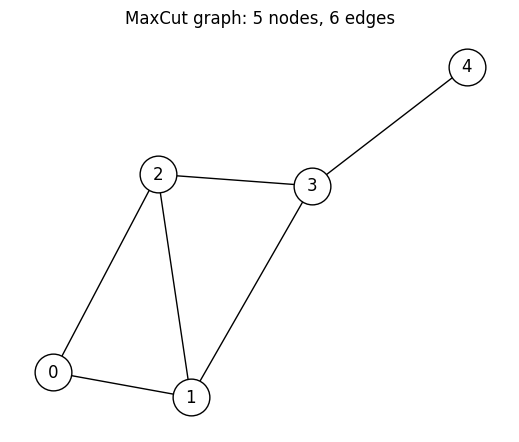

In [3]:
G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)])
num_nodes = G.number_of_nodes()

ising_quad: dict[tuple[int, int], float] = {
    tuple(sorted((i, j))): 1.0 for i, j in G.edges()
}
ising_linear: dict[int, float] = {}
spin_model = BinaryModel.from_ising(linear=ising_linear, quad=ising_quad)
# The problem structure is fully determined by the graph: one quad term per edge
# and no linear terms for unweighted MaxCut. Assert so a regression in
# `BinaryModel.from_ising` is caught when this notebook runs in CI.
assert len(spin_model.quad) == G.number_of_edges()
assert len(spin_model.linear) == 0

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(5, 4))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"MaxCut graph: {num_nodes} nodes, {G.number_of_edges()} edges")
plt.show()

## Building the QAOA ansatz with `@qkernel`

We write the QAOA ansatz directly as a small `@qkernel`.
The recipe is the same as in the [QAOA for MaxCut tutorial](../algorithm/qaoa_maxcut.ipynb): start from a uniform superposition, apply $p$ rounds of cost and mixer layers, then measure in the computational basis.

:::{tip}
Qamomile's rotation gates follow the $e^{-i\theta/2}$ convention.
Because of that, the $1/2$ factor is handled slightly differently in the cost and mixer layers.
In the mixer layer, we pass $2\beta$ to `rx`, so the $1/2$ cancels and we get the textbook $e^{-i\beta X}$.
In the cost layer, we pass $J_{ij} \cdot \gamma$ to `rzz`, so the $1/2$ remains.
This coefficient difference is absorbed into the variational parameter $\gamma$: the $\gamma$ used here is twice the textbook QAOA $\gamma$.
:::

In [4]:
@qmc.qkernel
def superposition(n: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    return q


@qmc.qkernel
def cost_layer(
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    q: qmc.Vector[qmc.Qubit],
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    for (i, j), Jij in quad.items():
        q[i], q[j] = qmc.rzz(q[i], q[j], angle=Jij * gamma)
    for i, hi in linear.items():
        q[i] = qmc.rz(q[i], angle=hi * gamma)
    return q


@qmc.qkernel
def mixer_layer(
    q: qmc.Vector[qmc.Qubit],
    beta: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    n = q.shape[0]
    for i in qmc.range(n):
        q[i] = qmc.rx(q[i], angle=2.0 * beta)
    return q


@qmc.qkernel
def qaoa_ansatz(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.measure(q)

`qaoa_ansatz.draw(...)` renders the Qamomile circuit diagram.
We pass concrete values for the arguments that determine the problem structure (`p`, `quad`, `linear`, `n`) so the layered shape is visible.
Meanwhile, `gammas` / `betas` remain symbolic parameters.

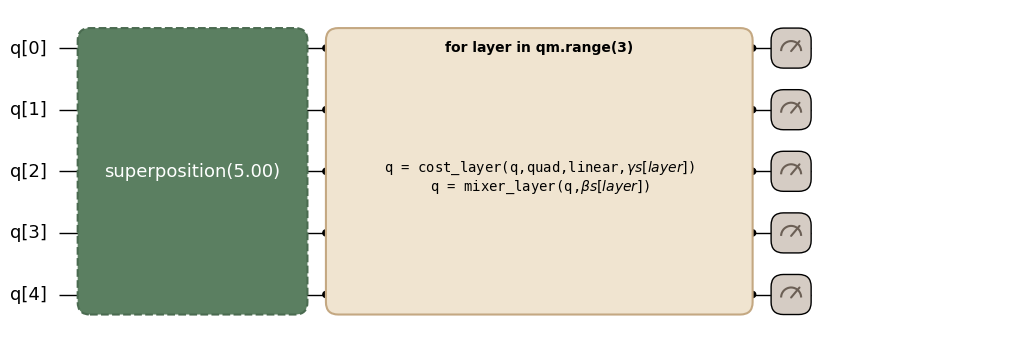

In [5]:
p = 3  # number of QAOA layers
qaoa_ansatz.draw(
    p=p,
    quad=spin_model.quad,
    linear=spin_model.linear,
    n=num_nodes,
)

## Transpile to QURI Parts

`QuriPartsTranspiler` is used with `transpile()` the same way as any other backend.
We bind the arguments that determine the problem structure and keep `gammas` / `betas` as runtime parameters.

In [6]:
transpiler = QuriPartsTranspiler()
executor = QuriPartsExecutor()

executable = transpiler.transpile(
    qaoa_ansatz,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
    },
    parameters=["gammas", "betas"],
)

`executable.get_first_circuit()` returns the underlying QURI Parts circuit.
The returned circuit is a QURI Parts `LinearMappedParametricQuantumCircuit`, and the $2p$ QAOA angles (`gammas[0..p-1]`, `betas[0..p-1]`) remain available as named runtime parameters.
We can confirm that with `type(...)` and the parameter count, then inspect the circuit directly with QURI Parts' built-in `draw_circuit`.

In [7]:
quri_circuit = executable.get_first_circuit()
assert quri_circuit is not None  # transpile() always emits one quantum segment here
# `qubit_count` and `parameter_count` are fully determined by the problem setting:
# one qubit per graph node, and one runtime parameter per (gamma | beta) per layer.
# Assert them so docs tests catch a regression in the QuriParts emit pass.
assert quri_circuit.qubit_count == num_nodes
assert quri_circuit.parameter_count == 2 * p
print(type(quri_circuit).__name__)
print("qubit_count    :", quri_circuit.qubit_count)
print("parameter_count:", quri_circuit.parameter_count)

draw_circuit(quri_circuit, line_length=200)

LinearMappedParametricQuantumCircuit
qubit_count    : 5
parameter_count: 6
   ___     ___     ___     ___                     ___     ___     ___                     ___     ___     ___                                  
  | H |   |PPR|   |PPR|   |PRX|                   |PPR|   |PPR|   |PRX|                   |PPR|   |PPR|   |PRX|                                 
--|0  |---|5  |---|6  |---|11 |-------------------|16 |---|17 |---|22 |-------------------|27 |---|28 |---|33 |---------------------------------
  |___|   |   |   |_ _|   |___|                   |   |   |_ _|   |___|                   |   |   |_ _|   |___|                                 
   ___    |   |    | |     ___     ___     ___    |   |    | |     ___     ___     ___    |   |    | |     ___     ___     ___                  
  | H |   |   |    | |    |PPR|   |PPR|   |PRX|   |   |    | |    |PPR|   |PPR|   |PRX|   |   |    | |    |PPR|   |PPR|   |PRX|                 
--|1  |---|   |----| |----|7  |---|8  |---|12 |---|   |

Each runtime parameter remains unbound until execution time.
That means binding `gammas` / `betas` is treated as a parameter-value update on the QURI Parts side rather than a circuit rebuild.
The problem structure, such as the Ising coefficients, qubit count, and number of layers, is fixed at compile time, leaving only the variational angles as runtime inputs.

## Sampling QAOA with `QuriPartsExecutor`

`executable.sample(executor, bindings=..., shots=...)` returns a `SampleJob`.
Calling `.result()` gives a `SampleResult`, which `BinaryModel.decode_from_sampleresult` decodes into a `BinarySampleSet` of spin variables $(+1 / -1)$.
This lets us count cut edges without any additional conversion.
`QuriPartsExecutor()` runs against the Qulacs state-vector simulator by default.

In [8]:
rng = np.random.default_rng(42)
init_params = rng.uniform(-np.pi / 2, np.pi / 2, 2 * p)
init_gammas = list(init_params[:p])
init_betas = list(init_params[p:])
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
sample_shots = 256 if docs_test_mode else 2000
maxiter = 20 if docs_test_mode else 100

sample_result = executable.sample(
    executor,
    bindings={"gammas": init_gammas, "betas": init_betas},
    shots=sample_shots,
).result()

decoded = spin_model.decode_from_sampleresult(sample_result)
print(f"Mean energy at random init: {decoded.energy_mean():+.4f}")

Mean energy at random init: -0.5530


## Optimizing the QAOA parameters

A QAOA optimization loop reuses the same `executable` across many `(gammas, betas)` vectors.
Call `transpiler.transpile()` once, then call `executable.sample()` many times.
In this example, we define the sampling and decoding work as `cost_fn()` and optimize it with SciPy's `minimize` function.
The classical optimizer updates `(gammas, betas)` while lowering the mean sampled Ising energy.
Each iteration reuses the same `executable` and `QuriPartsExecutor`.

In [9]:
cost_history: list[float] = []


def cost_fn(params: np.ndarray) -> float:
    result = executable.sample(
        executor,
        bindings={"gammas": list(params[:p]), "betas": list(params[p:])},
        shots=sample_shots,
    ).result()
    energy = spin_model.decode_from_sampleresult(result).energy_mean()
    cost_history.append(energy)
    return energy


res = minimize(cost_fn, init_params, method="COBYLA", options={"maxiter": maxiter})

opt_gammas = list(res.x[:p])
opt_betas = list(res.x[p:])
print(f"Optimized mean energy: {res.fun:+.4f}")
print(f"Optimal gammas       : {[round(float(v), 4) for v in opt_gammas]}")
print(f"Optimal betas        : {[round(float(v), 4) for v in opt_betas]}")

Optimized mean energy: -1.9470
Optimal gammas       : [1.2021, -0.3629, 1.3654]
Optimal betas        : [0.7042, -0.9493, 2.9318]


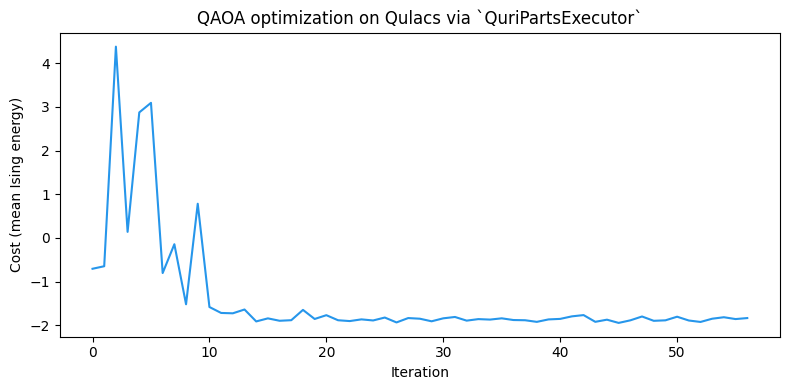

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean Ising energy)")
plt.title("QAOA optimization on Qulacs via `QuriPartsExecutor`")
plt.tight_layout()
plt.show()

The Qulacs sampler used inside `QuriPartsExecutor` does not seed its per-shot RNG, so the optimization trajectory and final energy will vary slightly across runs.
The optimizer should still converge close to the ground-state energy of $H_C$ on this 5-node graph.
The optimized parameters from this run (`opt_gammas`, `opt_betas`) are reused throughout the rest of this page.

## Expectation values: unbound circuits and bound circuits

`QuriPartsExecutor.estimate_expectation(circuit, hamiltonian, param_values)` is the method for computing expectation values with QURI Parts.
It chooses between two QURI Parts estimators depending on the **state of the circuit it receives**:

- **Unbound parametric circuit**: the circuit produced by `transpile()` still keeps its parameters as free variables.
  QURI Parts' `apply_circuit` wraps it as a `ParametricCircuitQuantumState`, and the executor calls QURI Parts' **parametric estimator**.
  On this path, `param_values` is used to bind the parameters at evaluation time.
- **Bound circuit, or a circuit with no parameters from the start**: once parameters are fixed to concrete values, for example with `circuit.bind_parameters([...])`, the same `apply_circuit` call returns a `GeneralCircuitQuantumState`.
  In this case, the executor calls QURI Parts' **non-parametric estimator**, and `param_values` is ignored.

This distinction helps when estimating computation cost.
The parametric estimator is a good fit for optimization loops that evaluate the same circuit many times with different parameters, because it avoids a circuit copy at each iteration.
If the parameters are already fixed to concrete values, the non-parametric estimator can be more efficient because it avoids parametric-circuit bookkeeping.

QURI Parts treats `measure` as a no-op at the circuit level.
Therefore, the parametric circuit emitted by `transpiler.transpile(qaoa_ansatz, ...)` can be used directly as the QAOA state preparation circuit for $|\boldsymbol{\gamma}, \boldsymbol{\beta}\rangle$.
We can pass it to `estimate_expectation` together with the cost Hamiltonian to compute $\langle H_C \rangle$ without sampling noise.
In a QAOA optimizer, you can keep the same circuit and replace `executable.sample()` plus decoding with `executor.estimate(circuit, hamiltonian, params=...)`.

To exercise both paths directly, first build a Qamomile `Hamiltonian` for $H_C = \sum_{(i,j) \in E} Z_i Z_j$.
Then convert it to a QURI Parts operator and call `estimate_expectation` for each circuit variant.

In [11]:
cost_hamiltonian = qm_o.Hamiltonian()
for (i, j), Jij in spin_model.quad.items():
    cost_hamiltonian.add_term(
        (qm_o.PauliOperator(qm_o.Pauli.Z, i), qm_o.PauliOperator(qm_o.Pauli.Z, j)),
        Jij,
    )
for i, hi in spin_model.linear.items():
    cost_hamiltonian.add_term((qm_o.PauliOperator(qm_o.Pauli.Z, i),), hi)

quri_H = hamiltonian_to_quri_operator(cost_hamiltonian)

# The unbound parametric circuit straight out of transpiler.transpile().
unbound_circuit = executable.get_first_circuit()
assert unbound_circuit is not None
print(f"unbound type           : {type(unbound_circuit).__name__}")
print(f"unbound parameter_count: {unbound_circuit.parameter_count}")

# QURI Parts requires the runtime parameters as a flat list in the order
# they were registered on the circuit, which is the first-use order during
# circuit emission. For QAOA that means gammas[0], betas[0], gammas[1], betas[1],
# ..., interleaved per layer, NOT all gammas followed by all betas.
# Read the order from the executable and build the flat list by lookup so
# we never have to guess the convention.
named_values = {f"gammas[{i}]": opt_gammas[i] for i in range(p)}
named_values.update({f"betas[{i}]": opt_betas[i] for i in range(p)})
flat_params = [named_values[name] for name in executable.parameter_names]
# The runtime parameter set is the 2p QAOA angles; assert this so a future
# change to how QuriPartsTranspiler registers parameters is caught here.
assert len(executable.parameter_names) == 2 * p
assert len(flat_params) == 2 * p
print(f"circuit parameter order: {executable.parameter_names}")

# Manually bind the same numeric values using QURI Parts' native binding operation.
bound_circuit = unbound_circuit.bind_parameters(flat_params)
print(f"bound   type           : {type(bound_circuit).__name__}")

# Path 1: unbound -> parametric estimator. param_values is consumed.
energy_unbound = executor.estimate_expectation(unbound_circuit, quri_H, flat_params)

# Path 2: bound -> non-parametric estimator. param_values is ignored.
energy_bound = executor.estimate_expectation(bound_circuit, quri_H, [])

print(f"parametric  estimator: {energy_unbound:+.10f}")
print(f"non-param.  estimator: {energy_bound:+.10f}")
assert np.isclose(energy_unbound, energy_bound, atol=1e-10)

unbound type           : LinearMappedParametricQuantumCircuit
unbound parameter_count: 6
circuit parameter order: ['gammas[0]', 'betas[0]', 'gammas[1]', 'betas[1]', 'gammas[2]', 'betas[2]']
bound   type           : ImmutableBoundParametricQuantumCircuit
parametric  estimator: -1.8593370765
non-param.  estimator: -1.8593370765


Both paths agree to numerical precision.
They evaluate the same QAOA state against the same Ising cost Hamiltonian.
The resulting noise-free expectation value at the optimized parameters should also match the sample-mean energy printed earlier within shot noise.
This path selection is hidden inside Qamomile's `executor.estimate()` interface, so you normally do not need to think about it.
Call `estimate_expectation` directly only when you need to manage the QURI Parts circuit yourself.

`executor.estimate(circuit, hamiltonian, params=...)` is the higher-level method.
It accepts a `qamomile.observable.Hamiltonian` directly, converts it automatically, and then delegates to `estimate_expectation`.

In [12]:
energy_via_estimate = executor.estimate(
    unbound_circuit, cost_hamiltonian, params=flat_params
)
print(f"executor.estimate     : {energy_via_estimate:+.10f}")
assert np.isclose(energy_via_estimate, energy_unbound, atol=1e-10)

executor.estimate     : -1.8593370765


## Swapping the sampler and estimator

`QuriPartsExecutor()` lazily creates the default Qulacs state-vector sampler and parametric estimator on first use.
To swap in a different QURI Parts backend, pass a sampler or estimator through `QuriPartsTranspiler.executor(sampler=..., estimator=...)`, or instantiate `QuriPartsExecutor(sampler=..., estimator=...)` directly.
The custom executor can be used anywhere `executor` appeared above.
Swapping the sampler does not require re-transpiling the kernel.
The executable carries the circuit, while the executor carries the simulation backend.

As a concrete example, we build a noisy sampler with QURI Parts' Qulacs `NoiseSimulator`.
Then we compare the noiseless and noisy sample-mean energies at the **same** optimized parameters.
With depolarizing noise applied to every gate, the noisy mean energy should drift away from the noise-free value.
This confirms that the swapped sampler is actually being used.

In [13]:
noise_model = NoiseModel([DepolarizingNoise(error_prob=0.02)])
noisy_sampler = create_qulacs_noisesimulator_sampler(noise_model)
noisy_executor = transpiler.executor(sampler=noisy_sampler)

clean_result = executable.sample(
    executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
    shots=sample_shots,
).result()
noisy_result = executable.sample(
    noisy_executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
    shots=sample_shots,
).result()

clean_decoded = spin_model.decode_from_sampleresult(clean_result)
noisy_decoded = spin_model.decode_from_sampleresult(noisy_result)
clean_energy = clean_decoded.energy_mean()
noisy_energy = noisy_decoded.energy_mean()
print(f"noiseless sampler mean energy: {clean_energy:+.4f}")
print(f"noisy     sampler mean energy: {noisy_energy:+.4f}")

noiseless sampler mean energy: -1.8630
noisy     sampler mean energy: -0.9550


Because both sampler runs return shot counts, we can compare their sampled energy distributions directly.
The vertical line in each subplot marks the sample mean energy.

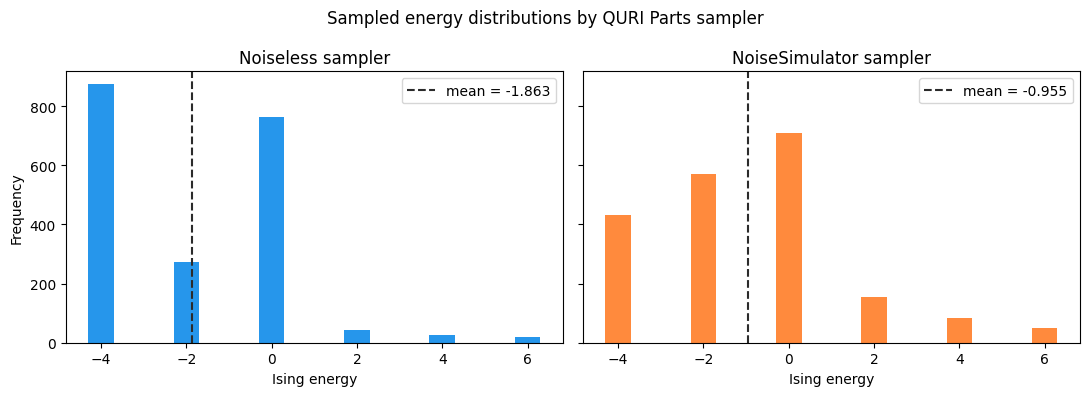

In [14]:


def energy_distribution(decoded_samples):
    counts: Counter[float] = Counter()
    for energy, occ in zip(decoded_samples.energy, decoded_samples.num_occurrences):
        counts[energy] += occ
    energies = sorted(counts.keys())
    return energies, [counts[energy] for energy in energies]


fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, decoded_samples, mean_energy, title, color in [
    (axes[0], clean_decoded, clean_energy, "Noiseless sampler", "#2696EB"),
    (
        axes[1],
        noisy_decoded,
        noisy_energy,
        "NoiseSimulator sampler",
        "#FF8A3D",
    ),
]:
    energies, counts = energy_distribution(decoded_samples)
    ax.bar(energies, counts, width=0.6, color=color)
    ax.axvline(
        mean_energy,
        color="#2B2B2B",
        linestyle="--",
        linewidth=1.5,
        label=f"mean = {mean_energy:+.3f}",
    )
    ax.set_xticks(energies)
    ax.set_title(title)
    ax.set_xlabel("Ising energy")
    ax.legend()

axes[0].set_ylabel("Frequency")
fig.suptitle("Sampled energy distributions by QURI Parts sampler")
fig.tight_layout()
plt.show()

Depolarizing noise pushes the QAOA state toward the maximally mixed state.
In that limit, every spin configuration is equally likely, and the mean of $H_C$ converges to $0$.
The noisy mean energy is therefore closer to 0, meaning higher, than the noiseless one.
Increasing `error_prob` or adding more noise channels pushes the noisy energy further toward $0$.
Setting `error_prob=0.0` recovers the noiseless value within shot noise.
The same pattern applies when swapping in any other QURI Parts sampler, such as a remote device, a density-matrix simulator, or a stochastic state-vector sampler.
In all cases, the kernel does not need to be transpiled again.

## Summary

- `QuriPartsTranspiler().transpile(kernel, bindings=..., parameters=[...])` converts the kernel to a QURI Parts `LinearMappedParametricQuantumCircuit`, which can be inspected with QURI Parts' native `draw_circuit`.
- `QuriPartsExecutor` supports both `executable.sample()` for QAOA-style sampling and `executor.estimate(...)` for noise-free expectation values, against the Qulacs state-vector simulator by default.
- `estimate_expectation` switches between QURI Parts' parametric and non-parametric estimators depending on whether the input circuit still has free parameters. Usually, `executor.estimate()` lets you use this behavior without thinking about the switch.
- Custom samplers and estimators, including QURI Parts' `NoiseSimulator`-backed sampler, can be passed through `transpiler.executor(...)` without re-transpiling the kernel.

### See also

- [CUDA-Q Support](cudaq_support.ipynb) covers the same MaxCut QAOA workflow on the CUDA-Q backend.